### Анализ данных по эффективности диеты

In [1]:
import pandas as pd
import seaborn as sns
from scipy import stats

# anova model from formula
from statsmodels.formula.api import ols
# anova table from ols model
from statsmodels.stats.anova import anova_lm
# for qqplot
import statsmodels.api as sm
# tukey test
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
data = pd.read_csv('data/diet.csv')
data.head()

,gender,diet,preweight,weight6weeks
0,M,B,60,60.0
1,M,B,103,103.0
2,F,A,58,54.2
3,F,A,60,54.0
4,F,A,64,63.3


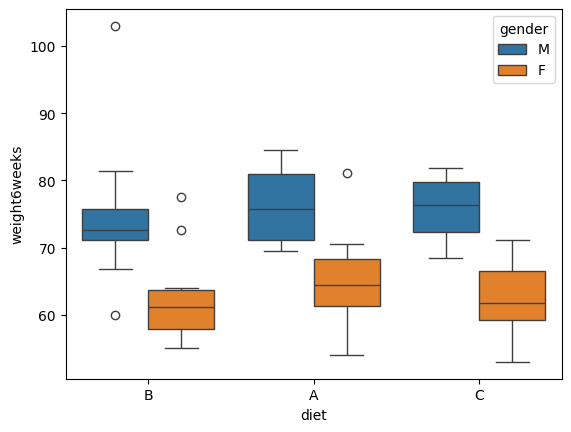

In [3]:
sns.boxplot(data=data, x='diet', y='weight6weeks', hue='gender');

### One-way ANOVA

<b>Шаг 1. Постановка гипотез:</b>
    
$H_0$: среднее значение веса после окончания эксперимента у мужчин и женщин равны.

$H_1$: среднее значение веса после окончания эксперимента у мужчин и женщин различаются.

<b>Шаг 2. Выбор уровня значимости:</b>
$$\alpha = 0.05$$

<b>Шаг 3. Проведение дисперсионного анализа:</b>

In [4]:
sample_f = data[data.gender == 'F'].weight6weeks
sample_m = data[data.gender == 'M'].weight6weeks

In [5]:
stats.f_oneway(sample_f, sample_m)

F_onewayResult(statistic=np.float64(66.16218641135315), pvalue=np.float64(6.097208570818812e-12))

In [6]:
model = ols('weight6weeks ~ gender', data).fit()
anova_lm(model)

,df,sum_sq,mean_sq,F,PR(>F)
gender,1.0,2854.201553,2854.201553,66.162186,6.097209e-12
Residual,76.0,3278.599601,43.139468,NaN,NaN


<b>Шаг 4. Проверка применимости метода:</b>
- Нормальность распределения факторов или остатков.
- Гомоскедастичность (дисперсия внутри каждой группы должна быть примерно одинаковой).

In [7]:
stats.shapiro(model.resid)

ShapiroResult(statistic=np.float64(0.9333086171627877), pvalue=np.float64(0.0005136699193614193))

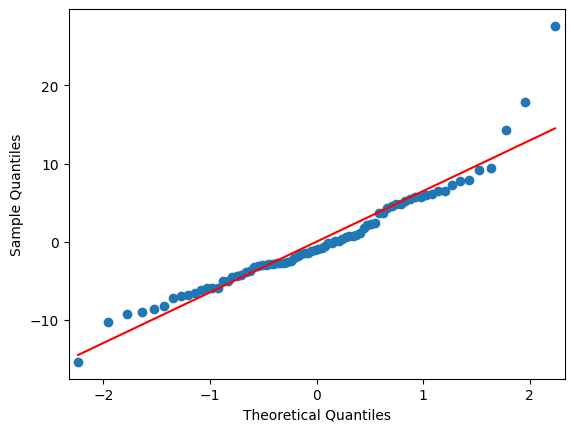

In [8]:
sm.qqplot(model.resid, line='s');

In [12]:
stats.bartlett(sample_f, sample_m)

BartlettResult(statistic=np.float64(0.6939274163080743), pvalue=np.float64(0.40483172475647555))

2. Влияет ли тип диеты (А/В/С), которой придерживается пациент, на значение веса после эксперимента?

In [13]:
model = ols('weight6weeks ~ diet', data).fit()
anova_lm(model)

,df,sum_sq,mean_sq,F,PR(>F)
diet,2.0,29.841339,14.920670,0.183362,0.832839
Residual,75.0,6102.959815,81.372798,NaN,NaN


### Two-way ANOVA

<b>Вопросы:</b>
1. Влияет ли пол пациента на значение веса после эксперимента?
2. Влияет ли тип диеты (А/В/С), которой придерживается пациент, на значение веса после эксперимента?
3. Есть ли эффект взаимодействия между полом пациента и типом диеты? Например, более сильное влияние определенного типа диеты только на женщин.

<b>Шаг 1. Постановка гипотез:</b>
    
$H_0$: среднее значение веса после окончания эксперимента у групп мужчин и женщин с различными типами диет(А/В/С) одинаково.

$H_1$: среднее значение веса после окончания эксперимента у групп мужчин и женщин с различными типами диет(А/В/С) различаются.

<b>Шаг 2. Выбор уровня значимости:</b>
$$\alpha = 0.05$$

<b>Шаг 3. Проведение дисперсионного анализа:</b>

In [18]:
model = ols('weight6weeks ~ diet + gender + diet:gender', data).fit()
anova_lm(model)

,df,sum_sq,mean_sq,F,PR(>F)
diet,2.0,29.841339,14.920670,0.335607,7.160162e-01
gender,1.0,2891.375733,2891.375733,65.035052,1.162414e-11
diet:gender,2.0,10.555631,5.277816,0.118713,8.882364e-01
Residual,72.0,3201.028451,44.458728,NaN,NaN


<b>Шаг 4. Проверка применимости метода:</b>
- Нормальность распределения факторов или остатков.
- Гомоскедастичность (дисперсия внутри каждой группы должна быть примерно одинаковой).

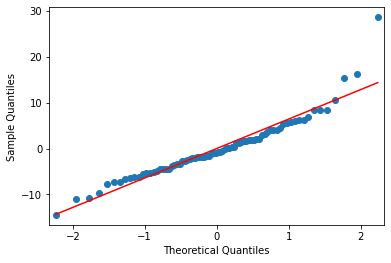

In [23]:
sm.qqplot(model.resid, line='s');

In [29]:
sample_a_f = data[(data.diet == 'A') & (data.gender == 'F')].weight6weeks
sample_b_f = data[(data.diet == 'B') & (data.gender == 'F')].weight6weeks
sample_c_f = data[(data.diet == 'C') & (data.gender == 'F')].weight6weeks

sample_a_m = data[(data.diet == 'A') & (data.gender == 'M')].weight6weeks
sample_b_m = data[(data.diet == 'B') & (data.gender == 'M')].weight6weeks
sample_c_m = data[(data.diet == 'C') & (data.gender == 'M')].weight6weeks

In [30]:
stats.bartlett(sample_a_f, sample_b_f, sample_c_f, sample_a_m, sample_b_m, sample_c_m)

BartlettResult(statistic=9.54750655147314, pvalue=0.08911993500142686)